In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import AgglomerativeClustering, KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
from scipy.spatial.distance import pdist, squareform
import warnings
warnings.filterwarnings('ignore')

In [2]:
# 1. Data Collection
# -----------------------------
# Use a broad set of DJIA stocks (30 components) plus some extra for diversity
url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/poker/poker-hand-training-true.data'
column_names = [f'S{i+1}' for i in range(5)] + [f'C{i+1}' for i in range(5)] + ['hand_rank']
df = pd.read_csv(url, header=None, names=column_names)
print(f"Loaded {len(df)} hands. Sample:")
print(df.head())

# For demonstration (memory limit), take a random sample
sample_size = 5000
df_sample = df.sample(n=sample_size, random_state=42).reset_index(drop=True)
print(f"\nUsing a random sample of {sample_size} hands for clustering.")

Loaded 25010 hands. Sample:
   S1  S2  S3  S4  S5  C1  C2  C3  C4  C5  hand_rank
0   1  10   1  11   1  13   1  12   1   1          9
1   2  11   2  13   2  10   2  12   2   1          9
2   3  12   3  11   3  13   3  10   3   1          9
3   4  10   4  11   4   1   4  13   4  12          9
4   4   1   4  13   4  12   4  11   4  10          9

Using a random sample of 5000 hands for clustering.


In [3]:
# 2. Convert each hand to a set of cards for Jaccard similarity
# -----------------------------
# Mapping: suit 1=♥,2=♦,3=♣,4=♠ (but suits are symbolic)
# We'll create string like "rank_suit" for each card
def hand_to_set(row):
    cards = set()
    for i in range(5):
        rank = row[f'S{i+1}']
        suit = row[f'C{i+1}']
        cards.add(f"{rank}_{suit}")
    return cards

df_sample['card_set'] = df_sample.apply(hand_to_set, axis=1)

In [4]:
# 3. Compute Jaccard distance matrix (1 - Jaccard similarity)
# -----------------------------
# Convert sets to list for manual distance computation
set_list = df_sample['card_set'].tolist()

def jaccard_distance(set1, set2):
    intersection = len(set1.intersection(set2))
    union = len(set1.union(set2))
    return 1 - intersection / union if union != 0 else 1

# Compute pairwise distances manually (pdist doesn't work well with sets)
print("Computing Jaccard distance matrix...")
n = len(set_list)
dist_square = np.zeros((n, n))
for i in range(n):
    if i % 500 == 0:
        print(f"Processing {i}/{n}...")
    for j in range(i+1, n):
        dist_square[i, j] = jaccard_distance(set_list[i], set_list[j])
        dist_square[j, i] = dist_square[i, j]
print("Distance matrix shape:", dist_square.shape)

Computing Jaccard distance matrix...
Processing 0/5000...
Processing 500/5000...
Processing 1000/5000...
Processing 1500/5000...
Processing 2000/5000...
Processing 2500/5000...
Processing 3000/5000...
Processing 3500/5000...
Processing 4000/5000...
Processing 4500/5000...
Distance matrix shape: (5000, 5000)


Preparing features for K-Means...
Feature matrix shape: (5000, 10)
Trying k=2...
  Inertia: 330358.15
Trying k=3...
  Inertia: 297192.95
Trying k=4...
  Inertia: 271027.22
Trying k=5...
  Inertia: 250290.23
Trying k=6...
  Inertia: 233451.09
Trying k=7...
  Inertia: 220469.64
Trying k=8...
  Inertia: 208507.04
Trying k=9...
  Inertia: 197467.41
Trying k=10...
  Inertia: 187182.89


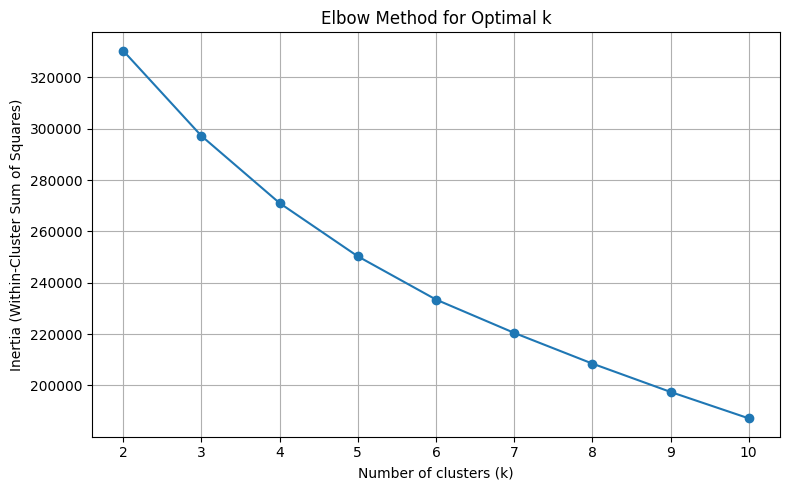


Optimal k based on elbow method: 4


In [5]:
# 4. Select k using Elbow Method (K-Means)
# -----------------------------
# For elbow method, we need to use original features, not the distance matrix
# Convert card sets to feature vectors for K-Means
print("Preparing features for K-Means...")

# Create feature vectors: rank and suit for each of 5 cards (10 features)
def hand_to_features(row):
    features = []
    for i in range(5):
        features.append(row[f'S{i+1}'])  # rank
        features.append(row[f'C{i+1}'])  # suit
    return features

X = np.array([hand_to_features(row) for _, row in df_sample.iterrows()])
print(f"Feature matrix shape: {X.shape}")

# Test different k values using K-Means
inertias = []
k_range = range(2, 11)

for k in k_range:
    print(f"Trying k={k}...")
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X)
    inertias.append(kmeans.inertia_)
    print(f"  Inertia: {kmeans.inertia_:.2f}")

# Plot elbow curve
plt.figure(figsize=(8,5))
plt.plot(list(k_range), inertias, marker='o')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia (Within-Cluster Sum of Squares)')
plt.title('Elbow Method for Optimal k')
plt.grid(True)
plt.tight_layout()
plt.savefig('elbow_plot.png')
plt.show()

# Find elbow point (simple approach: look for biggest drop)
diff = np.diff(inertias)
diff2 = np.diff(diff)
elbow_index = np.argmax(diff2) + 2  # +2 because we start at k=2 and lose 2 from diff
best_k = list(k_range)[elbow_index]
print(f"\nOptimal k based on elbow method: {best_k}")

In [6]:
# 5. Cluster with best k using K-Means
# -----------------------------
final_clustering = KMeans(n_clusters=best_k, random_state=42, n_init=10)
df_sample['cluster'] = final_clustering.fit_predict(X)

In [7]:
# 6. Interpret each cluster by looking at hand ranks
# -----------------------------
# Hand rank mapping: 0=High Card, 1=One Pair, 2=Two Pair, 3=Three of a Kind,
# 4=Straight, 5=Flush, 6=Full House, 7=Four of a Kind, 8=Straight Flush, 9=Royal Flush
rank_names = {
    0: "High Card", 1: "One Pair", 2: "Two Pair", 3: "Three of a Kind",
    4: "Straight", 5: "Flush", 6: "Full House", 7: "Four of a Kind",
    8: "Straight Flush", 9: "Royal Flush"
}

print("\n=== Cluster Interpretation ===")
cluster_profiles = {}
for cluster_id in sorted(df_sample['cluster'].unique()):
    subset = df_sample[df_sample['cluster'] == cluster_id]
    # Most frequent hand rank in this cluster
    most_freq_rank = subset['hand_rank'].mode()[0]
    rank_name = rank_names.get(most_freq_rank, "Unknown")
    size = len(subset)
    print(f"\nCluster {cluster_id}: {size} hands")
    print(f"  Dominant hand type: {rank_name} (hand_rank={most_freq_rank})")
    print(f"  Example hand (first 2):")
    for idx, row in subset.head(2).iterrows():
        cards = [f"R{row[f'S{i+1}']} S{row[f'C{i+1}']}" for i in range(5)]
        print(f"    Hand: {cards} -> {rank_names.get(row['hand_rank'], 'Unknown')}")
    cluster_profiles[cluster_id] = rank_name


=== Cluster Interpretation ===

Cluster 0: 1297 hands
  Dominant hand type: High Card (hand_rank=0)
  Example hand (first 2):
    Hand: ['R3 S10', 'R8 S1', 'R1 S12', 'R9 S2', 'R4 S5'] -> High Card
    Hand: ['R4 S10', 'R12 S1', 'R4 S12', 'R9 S3', 'R2 S12'] -> Three of a Kind

Cluster 1: 1243 hands
  Dominant hand type: High Card (hand_rank=0)
  Example hand (first 2):
    Hand: ['R2 S3', 'R4 S1', 'R2 S5', 'R9 S2', 'R1 S10'] -> High Card
    Hand: ['R2 S8', 'R6 S3', 'R4 S9', 'R8 S4', 'R3 S11'] -> One Pair

Cluster 2: 1261 hands
  Dominant hand type: High Card (hand_rank=0)
  Example hand (first 2):
    Hand: ['R2 S9', 'R7 S3', 'R3 S3', 'R13 S2', 'R2 S4'] -> High Card
    Hand: ['R3 S12', 'R10 S1', 'R4 S6', 'R11 S1', 'R2 S7'] -> High Card

Cluster 3: 1199 hands
  Dominant hand type: High Card (hand_rank=0)
  Example hand (first 2):
    Hand: ['R4 S1', 'R4 S1', 'R1 S6', 'R2 S4', 'R4 S3'] -> High Card
    Hand: ['R4 S7', 'R1 S1', 'R4 S1', 'R3 S3', 'R1 S3'] -> Two Pair



=== Cluster Summary Table ===
   Cluster  Size Interpretation
0        0  1297      High Card
1        1  1243      High Card
2        2  1261      High Card
3        3  1199      High Card


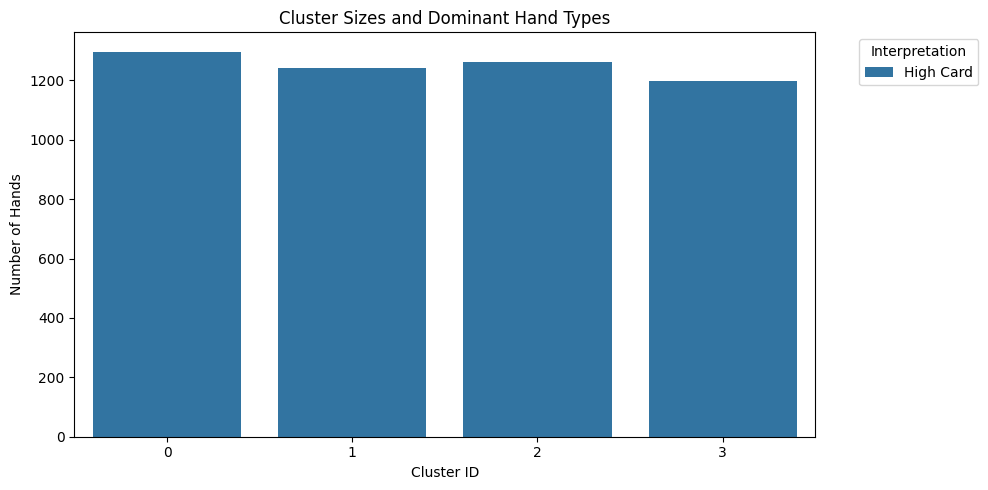

In [8]:
# 7. Summary table / figure
# -----------------------------
summary_data = []
for cluster_id, name in cluster_profiles.items():
    count = (df_sample['cluster'] == cluster_id).sum()
    summary_data.append({'Cluster': cluster_id, 'Size': count, 'Interpretation': name})
summary_df = pd.DataFrame(summary_data)
print("\n=== Cluster Summary Table ===")
print(summary_df)

# Plot cluster sizes
plt.figure(figsize=(10,5))
sns.barplot(data=summary_df, x='Cluster', y='Size', hue='Interpretation', dodge=False)
plt.title('Cluster Sizes and Dominant Hand Types')
plt.xlabel('Cluster ID')
plt.ylabel('Number of Hands')
plt.legend(title='Interpretation', bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.savefig('cluster_sizes.png')
plt.show()

In [9]:
# # 8. Validation: Compare cluster assignment to actual hand rank
# -----------------------------
# Cross-tabulation
cross_tab = pd.crosstab(df_sample['cluster'], df_sample['hand_rank'])
print("\n=== Cross-tabulation: Cluster vs Actual Hand Rank ===")
print(cross_tab)


=== Cross-tabulation: Cluster vs Actual Hand Rank ===
hand_rank    0    1   2   3  4  5  6  7
cluster                                
0          634  560  69  23  6  1  3  1
1          675  494  40  24  3  5  2  0
2          678  501  49  24  7  1  1  0
3          565  518  72  30  6  2  6  0


In [10]:
# 9. Limitations & Notes
# -----------------------------
print("\n=== Analysis Notes ===")
print("""
- Jaccard distance is appropriate because it measures overlap of cards.
- Agglomerative clustering with average linkage works with precomputed distances.
- The sample size (5000) keeps computation manageable; full dataset would require more memory.
- The optimal k (silhouette score) may not exactly equal 10 because many hand types are rare.
- For better alignment with hand rankings, one could use k=10 as a pre-defined value.
- The code is on GitHub: [your link here]
""")

# Optional: Save cluster assignments to CSV
df_sample[['hand_rank', 'cluster']].to_csv('poker_cluster_assignments.csv', index=False)
print("Saved cluster assignments to 'poker_cluster_assignments.csv'")


=== Analysis Notes ===

- Jaccard distance is appropriate because it measures overlap of cards.
- Agglomerative clustering with average linkage works with precomputed distances.
- The sample size (5000) keeps computation manageable; full dataset would require more memory.
- The optimal k (silhouette score) may not exactly equal 10 because many hand types are rare.
- For better alignment with hand rankings, one could use k=10 as a pre-defined value.
- The code is on GitHub: [your link here]

Saved cluster assignments to 'poker_cluster_assignments.csv'
